mean acceptance probability: 0.879


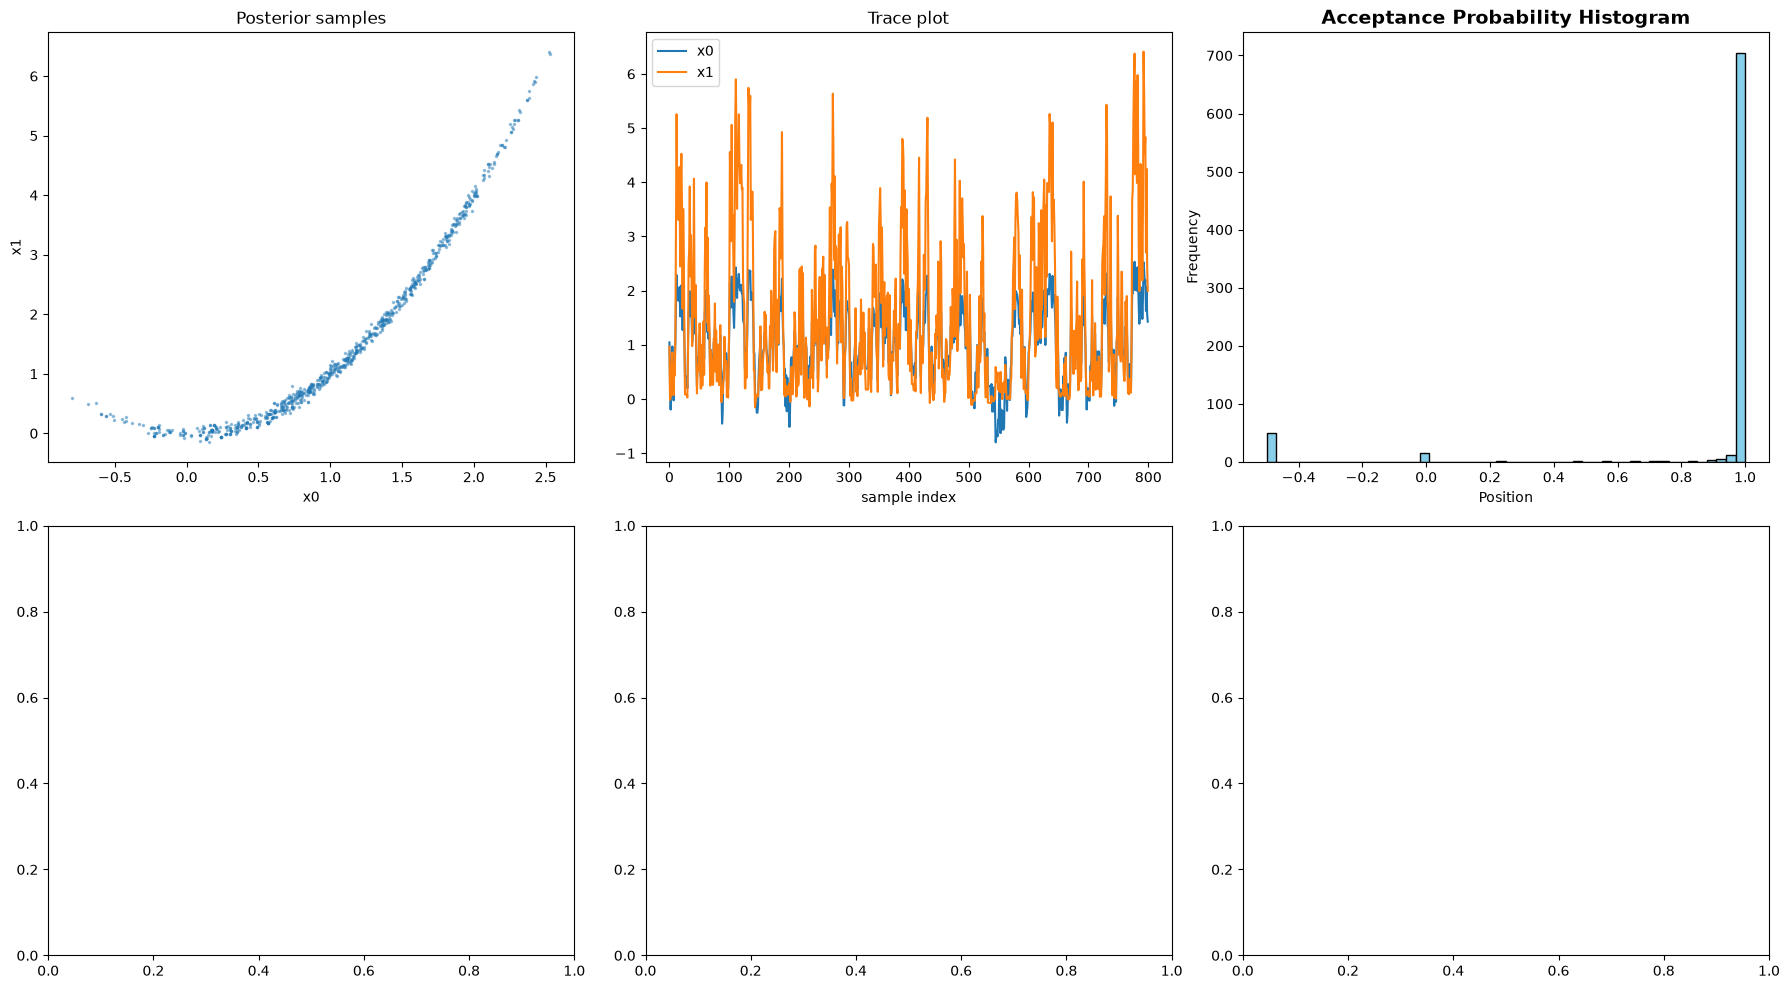

In [ ]:
import jax.numpy as jnp
import numpy as np
import jax
import jax.random as jr

from RMHMC2 import RMHMCSampler2
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

num_overall_steps = 1000
burn_in = 200
prior_cov_matrix = jnp.array([[1.0, 0],
                       [0, 1.0]])
inv_prior_cov_matrix = jnp.linalg.inv(prior_cov_matrix)
measurement_error_bar = 0.1
initial_position = jnp.array([0.0, 0.0])   
rng = jr.PRNGKey(2)

def negative_logdensity(x):
    return 100.0 * (x[1] - x[0]**2)**2 + (1.0 - x[0])**2
    log_P_data_given_signal = 0.5*((jnp.sum(jnp.exp(x)) - 1)/measurement_error_bar)**2
    log_P_signal = 0.5*x.T @ inv_prior_cov_matrix @ x
    return log_P_data_given_signal + log_P_signal

sampler = RMHMCSampler2(
    negative_logdensity,
    num_integration_steps=32,
    step_size=0.06,
    alpha=1.0,
    tolerance=1e-5,
    max_iterations=1000,
    track_leapfrog_positions = True
)

overall_position_arr, momenta, accept_prob_arr, overall_exact_position_arr = sampler.sample(initial_position, num_overall_steps, burn_in, rng)

print(f"mean acceptance probability: {float(jnp.mean(accept_prob_arr)):.3f}")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes[0][0].plot(overall_position_arr[:, 0], overall_position_arr[:, 1], '.', alpha=0.4, markersize=3)
axes[0][0].set_xlabel("x0"); axes[0][0].set_ylabel("x1"); axes[0][0].set_title("Posterior samples")

axes[0][1].plot(overall_position_arr[:, 0], label="x0")
axes[0][1].plot(overall_position_arr[:, 1], label="x1")
axes[0][1].set_xlabel("sample index"); axes[0][1].set_title("Trace plot"); axes[0][1].legend()

accept_prob_arr = jnp.ravel(accept_prob_arr)
axes[0][2].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')
axes[0][2].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[0][2].set_xlabel('Position')
axes[0][2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

An arbitrary fixed Hessian for the Rosenbrock function at coords ( 1.281865119934082, 1.560537338256836, ) is: [[1349.5989  -512.74603]
 [-512.74603  200.     ]]


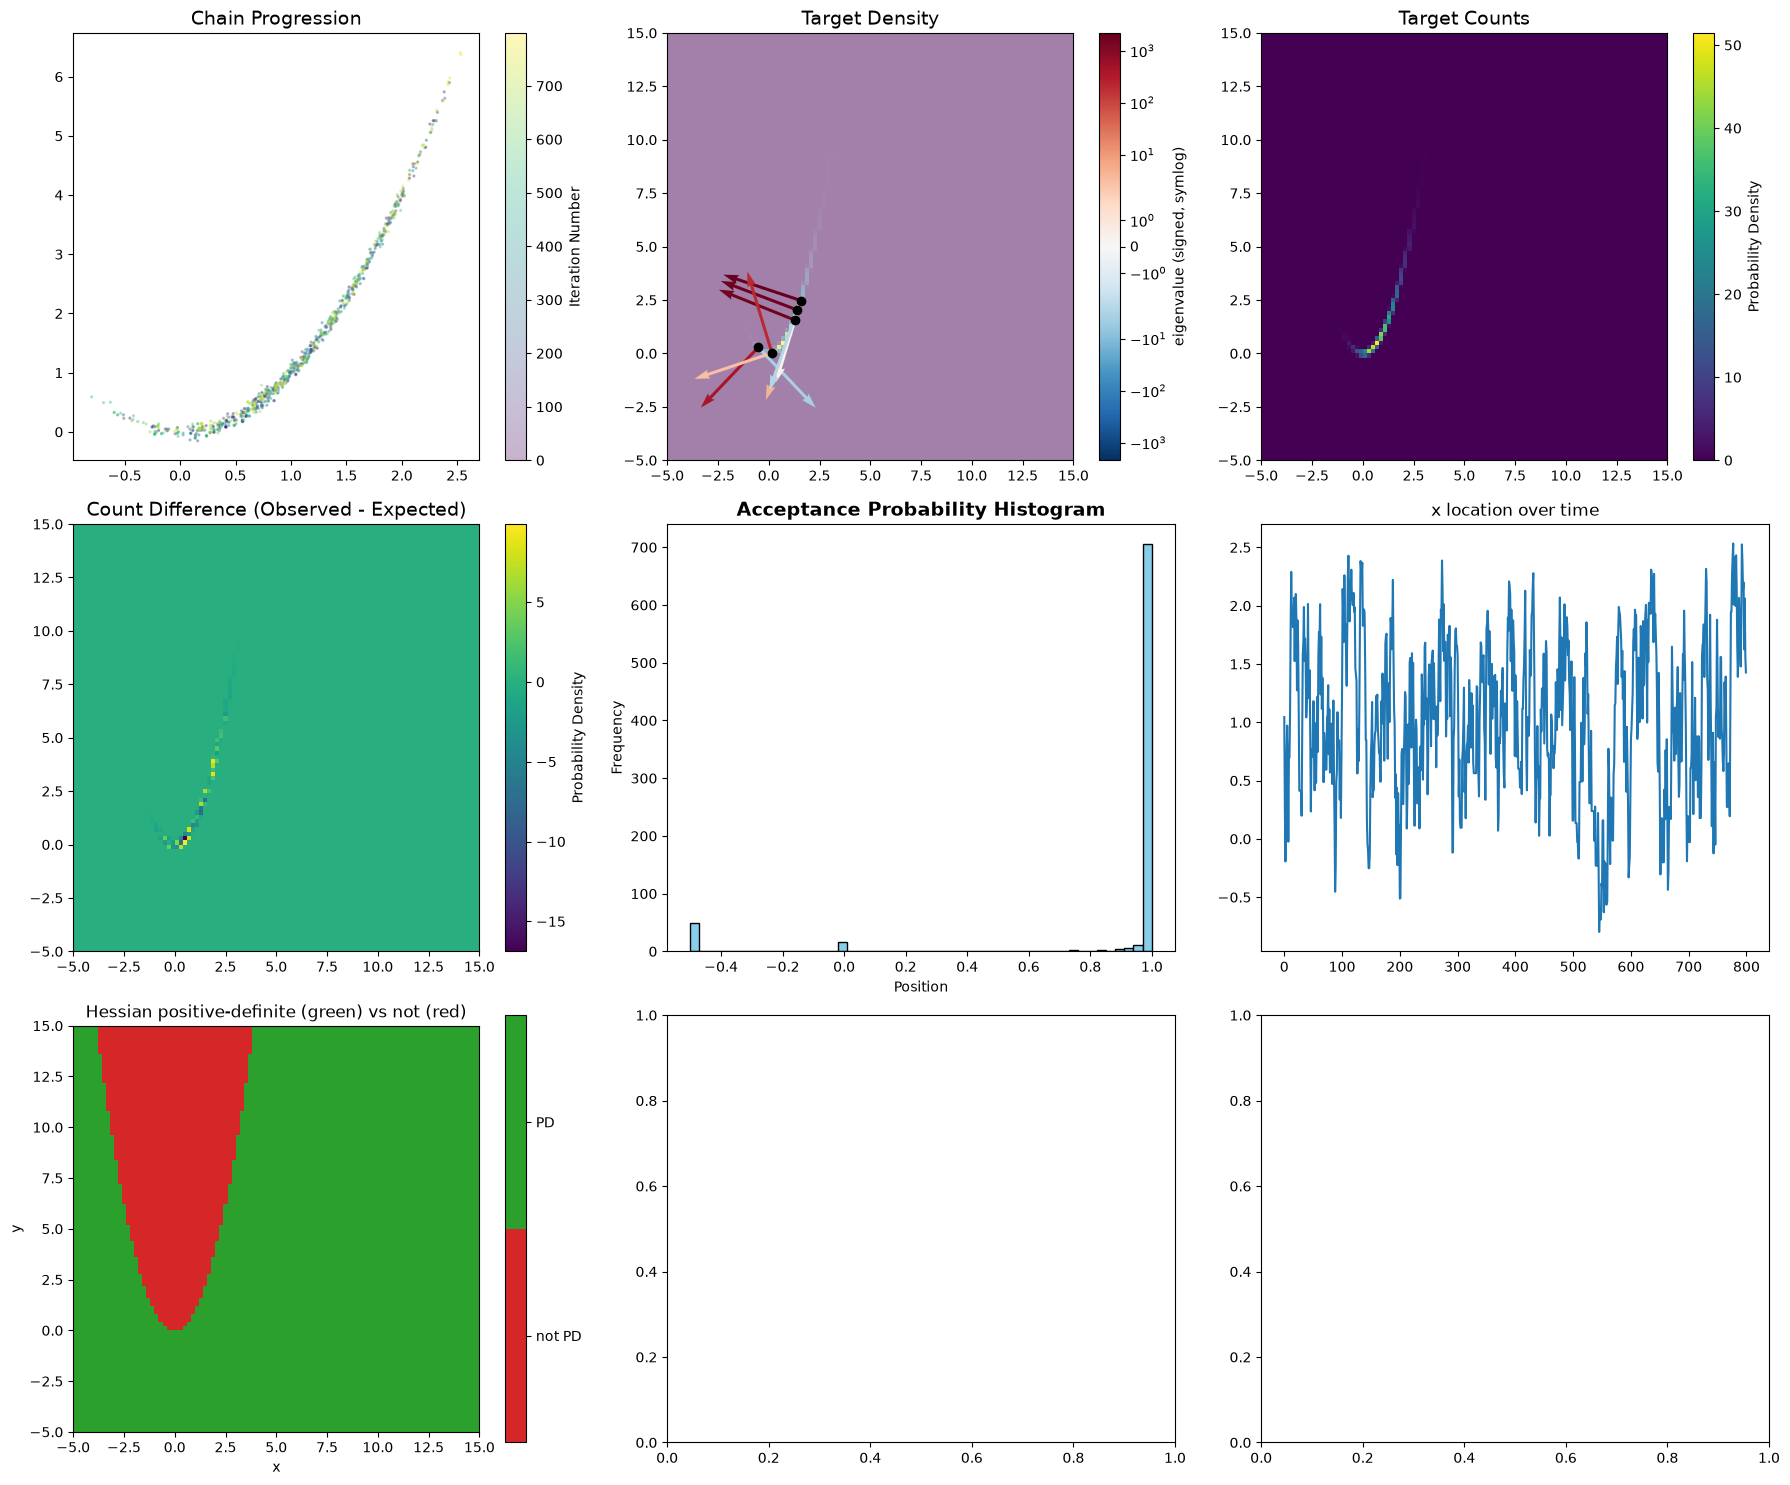

The covariance of the observed points is [[0.45291984 0.90342873]
 [0.90342873 2.0959506 ]]
KL_divergence is 0.1742829978466034
The KL divergence between a sampled discretized version of the analytical posterior density and the actual analytical posterior density is 0.000630462309345603


In [6]:
num_good_samples = num_overall_steps - burn_in


fig, axes = plt.subplots(3, 3, figsize=(18, 15))


indices = (jnp.arange(5) + 1)*100

hess = jax.hessian(negative_logdensity)

points = overall_position_arr[indices]  # shape (5, 2), from before

import matplotlib.colors as mcolors

cmap = plt.cm.RdBu_r  # red = positive curvature, blue = negative (RdBu_r puts red on high end)

# First pass: collect all eigenvalues to set a consistent color scale
all_eigvals = []
results = []

arb_hessian = hess(points[0])
print(f"An arbitrary fixed Hessian for the Rosenbrock function at coords ( {points[0][0]}, {points[0][1]}, ) is: {arb_hessian}")
for point in points:
    H = hess(point)
    H = (H + H.T) / 2  # symmetrize for numerical safety
    eigvals, eigvecs = jnp.linalg.eigh(H)
    all_eigvals.append(eigvals)
    results.append((point, eigvals, eigvecs))

all_eigvals = jnp.concatenate(all_eigvals)
abs_max = float(jnp.abs(all_eigvals).max())

# linthresh: the range near zero treated as linear rather than log.
# A common choice is a few orders of magnitude below the max.
linthresh = abs_max * 1e-3

norm = mcolors.SymLogNorm(linthresh=linthresh, vmin=-abs_max, vmax=abs_max)

# Second pass: plot
for point, eigvals, eigvecs in results:
    axes[0][1].plot(point[0], point[1], 'ko')

    for i in range(eigvecs.shape[1]):
        vec = eigvecs[:, i] * 2
        color = cmap(norm(float(eigvals[i])))  # signed eigenvalue, not abs
        axes[0][1].quiver(
            point[0], point[1],
            vec[0], vec[1],
            angles='xy', scale_units='xy', scale=0.5,
            color=color
        )

# Colorbar reflecting the signed log scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=axes[0][1], label='eigenvalue (signed, symlog)')


x_min = -5
x_max = 15
y_min = -5
y_max = 15
n_cells = 100        # number of rectangles per axis
k = 10               # sub-samples per axis per cell (k*k samples per cell)

# cell *edges*, not centers — n_cells rectangles need n_cells+1 boundary points
x_edges = jnp.linspace(x_min, x_max, n_cells + 1)
y_edges = jnp.linspace(y_min, y_max, n_cells + 1)
dx = x_edges[1] - x_edges[0]
dy = y_edges[1] - y_edges[0]

# midpoint-rule offsets within a cell, in (0, 1)
offsets = (jnp.arange(k) + 0.5) / k

# fine grid coords: for every cell, k points spread across its interior
x_fine = (x_edges[:-1, None] + offsets[None, :] * dx).ravel()  # shape (n_cells*k,)
y_fine = (y_edges[:-1, None] + offsets[None, :] * dy).ravel()

Xf, Yf = jnp.meshgrid(x_fine, y_fine)
pos_fine = jnp.stack([Xf.ravel(), Yf.ravel()], axis=-1)

Z_fine = jax.vmap(negative_logdensity)(pos_fine)
Z_fine = jnp.exp(-Z_fine).reshape(Xf.shape)          # shape (n_cells*k, n_cells*k)

# block-average: group each k x k sub-block back into one cell and mean it
Z_avg = Z_fine.reshape(n_cells, k, n_cells, k).mean(axis=(1, 3))  # shape (n_cells, n_cells)


total_prob_density = jnp.sum(Z_avg)*(x_max - x_min)*(y_max - y_min)/(n_cells**2)
normalized_density = Z_avg/total_prob_density
expected_bin_prob = normalized_density*(x_max - x_min)*(y_max - y_min)/(n_cells**2)
expected_counts = expected_bin_prob*num_good_samples
observed_counts = jnp.zeros(Z_avg.shape)
x_values = jnp.floor((overall_position_arr[:, 0] - x_min) * n_cells / (x_max - x_min)).astype(int)
y_values = jnp.floor((overall_position_arr[:, 1] - y_min) * n_cells / (y_max - y_min)).astype(int)
observed_counts = observed_counts.at[y_values, x_values].add(1)
observed_bin_prob = observed_counts/num_good_samples

trial_space = jnp.arange(num_overall_steps)
iterations = np.arange(len(overall_position_arr))

scatter2 = axes[0][0].scatter(overall_position_arr[:, 0], overall_position_arr[:, 1], 
                           c=iterations, cmap='viridis', alpha=0.3, s=2)
axes[0][0].set_title("Chain Progression", fontsize=14)
# For colorbars in subplots, you must tell it which axis to attach to
fig.colorbar(scatter2, ax=axes[0][0], label="Iteration Number") 

heatmap = axes[0][1].imshow(normalized_density, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto', alpha = 0.5)
axes[0][1].set_title("Target Density", fontsize = 14)
# Add a colorbar, labels, and title
#fig.colorbar(heatmap, ax=axes[0][1], label='Probability Density')

heatmap = axes[0][2].imshow(expected_counts, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[0][2].set_title("Target Counts", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[0][2], label='Probability Density')

heatmap = axes[1][0].imshow(observed_counts - expected_counts, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto')
axes[1][0].set_title("Count Difference (Observed - Expected)", fontsize = 14)
# Add a colorbar, labels, and title
fig.colorbar(heatmap, ax=axes[1][0], label='Probability Density')

axes[1][1].hist(accept_prob_arr, bins=50, edgecolor='black', color='skyblue')

# Add labels and a title to make it readable
axes[1][1].set_title('Acceptance Probability Histogram', fontsize=14, fontweight='bold')
axes[1][1].set_xlabel('Position')
axes[1][1].set_ylabel('Frequency')

axes[1][2].plot(iterations, overall_position_arr[:, 0])
axes[1][2].set_title("x location over time")




x_centers = (x_edges[:-1] + x_edges[1:]) / 2   # (n_cells,)
y_centers = (y_edges[:-1] + y_edges[1:]) / 2   # (n_cells,)
 
Xc, Yc = jnp.meshgrid(x_centers, y_centers)     # each (n_cells, n_cells)
pos_centers = jnp.stack([Xc.ravel(), Yc.ravel()], axis=-1)   # (n_cells*n_cells, 2)

@jax.jit
def is_positive_definite(xy):
    H = hess(xy)
    eigvals = jnp.linalg.eigvalsh(H)   # H is symmetric, so eigvalsh is exact + cheap
    return jnp.all(eigvals > 0)
 
is_pd_centers = jax.vmap(is_positive_definite)(pos_centers)   # (n_cells*n_cells,) bool
 
cell_is_pd = is_pd_centers.reshape(n_cells, n_cells)   # (y_cell, x_cell)

cmap = ListedColormap(["#d62728", "#2ca02c"])   # red = not PD, green = PD
mesh = axes[2][0].pcolormesh(
    np.asarray(x_edges), np.asarray(y_edges),
    np.asarray(cell_is_pd).astype(int),
    cmap=cmap, vmin=0, vmax=1, shading="flat",
)
 
axes[2][0].set_xlabel("x")
axes[2][0].set_ylabel("y")
axes[2][0].set_title("Hessian positive-definite (green) vs not (red)")
axes[2][0].set_aspect("equal")
 
cbar = fig.colorbar(mesh, ticks=[0.25, 0.75])
cbar.ax.set_yticklabels(["not PD", "PD"])
















plt.tight_layout()
plt.show()

def KL_divergence(expected_probs, observed_probs, jitter):
    usable_expected_probs = jnp.where(expected_probs == 0, jitter, expected_probs)
    usable_observed_probs = jnp.where(observed_probs == 0, jitter, observed_probs)
    KL_array = usable_expected_probs*(jnp.log(usable_expected_probs) - jnp.log(usable_observed_probs))
    return jnp.sum(KL_array)


chi_2_significance_mask = expected_counts >= 5

important_expected_counts = expected_counts[chi_2_significance_mask]
important_observed_counts = observed_counts[chi_2_significance_mask]
chi_2 = jnp.sum((important_observed_counts - important_expected_counts)**2/important_expected_counts)

cov = jnp.cov(overall_position_arr, rowvar=False)
print(f"The covariance of the observed points is {cov}")
print(f"KL_divergence is {KL_divergence(expected_bin_prob, observed_bin_prob, jitter = 1e-5)}")

linear_probs = normalized_density.ravel();
sampled_analytical_points = jnp.zeros(Z_avg.shape)
random_indices = jr.choice(rng, linear_probs.size, shape = (100000,), replace = True, p = linear_probs)
row_indices, col_indices = jnp.unravel_index(random_indices, normalized_density.shape)
sampled_analytical_points = sampled_analytical_points.at[row_indices, col_indices].add(1)
sampled_analytical_bin_prob = sampled_analytical_points/100000;
print(f"The KL divergence between a sampled discretized version of the analytical posterior density and the actual analytical posterior density is {KL_divergence(expected_bin_prob, sampled_analytical_bin_prob, jitter = 1e-5)}")

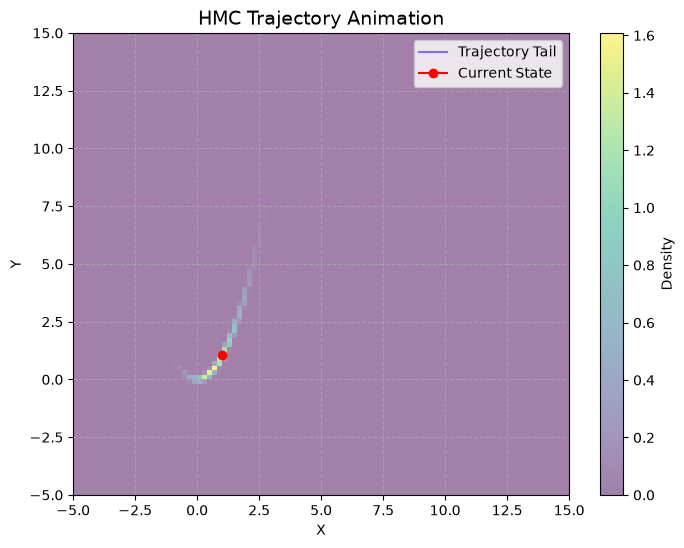

In [7]:
# Animate the first 100 positions! (after the burn in)
overall_exact_position_arr = overall_exact_position_arr.reshape(-1, overall_exact_position_arr.shape[-1])
positions = np.asarray(overall_exact_position_arr[:10, :])
import matplotlib.animation as animation
fig, ax = plt.subplots(figsize=(8, 6))


heatmap = ax.imshow(normalized_density, extent=[x_min, x_max, y_min, y_max], origin='lower', cmap='viridis', aspect='auto', alpha = 0.5, zorder = 0)
fig.colorbar(heatmap, ax=ax, label="Density")




ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_title("HMC Trajectory Animation", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, linestyle="--", alpha=0.6)

# 3. Initialize plot elements
# 'path' is the fading tail; 'head' is the current position of the sampler
path, = ax.plot([], [], color="blue", alpha=0.5, lw=1.5, label="Trajectory Tail")
head, = ax.plot([], [], color="red", marker="o", markersize=6, label="Current State")
ax.legend(loc="upper right")

# 4. Define the initialization function
def init():
    path.set_data([], [])
    head.set_data([], [])
    return path, head

# 5. Define the update function for each frame
def update(frame):
    # Determine how much history to show in the tail (e.g., last 50 recorded steps)
    tail_length = 50
    start_idx = max(0, frame - tail_length)
    
    # Extract coordinates for the trailing path
    tail_x = positions[start_idx:frame+1, 0]
    tail_y = positions[start_idx:frame+1, 1]
    
    # Extract coordinates for the active head
    current_x = positions[frame, 0]
    current_y = positions[frame, 1]
    
    # Update matplotlib elements (must pass sequences/lists, even for single points)
    path.set_data(tail_x, tail_y)
    head.set_data([current_x], [current_y])
    
    return path, head

# 6. Create the animation
# interval=50 means 50 milliseconds between frames
ani = animation.FuncAnimation(
    fig, update, frames=len(positions), init_func=init, blit=True, interval=50
)

# --- How to View / Save ---

# Choice A: Show it live interactively (Works in standard python scripts or native GUIs)
from IPython.display import HTML
HTML(ani.to_jshtml())